In [4]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 5.1 MB/s eta 0:00:20
   - -------------------------------------- 3.7/101.7 MB 13.0 MB/s eta 0:00:08
   -- ------------------------------------- 6.6/101.7 MB 13.1 MB/s eta 0:00:08
   --- ------------------------------------ 10.0/101.7 MB 14.5 MB/s eta 0:00:07
   ----- ---------------------------------- 13.1/101.7 MB 14.6 MB/s eta 0:00:07
   ------ --------------------------------- 16.5/101.7 MB 15.0 MB/s eta 0:00:06
   ------- -------------------------------- 19.1/101.7 MB 15.0 MB/s eta 0:00:06
   ------- -------------------------------- 20.2/101.7 MB 14.8 MB/s eta 0:00:06
   --------- ------------------------------ 23.9/101.7 MB 14.0 MB/s eta 0:00:06
   ---------- ----------------------------- 26.2/101.7 MB 13.6 MB/s eta 0:00:06
   ----------- ---------------------------- 29.9/101.7 MB 14.0 

In [6]:
pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 3.7 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries loaded!")

Libraries loaded!


In [8]:
df = pd.read_csv("E:/portfoilo/churn-prediction/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%

Missing values:
Series([], dtype: int64)


In [9]:
# ดู numeric columns
print(df.describe())
print("\nData types:")
print(df.dtypes)

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
Total

In [10]:
# TotalCharges เป็น object ต้องแปลงเป็น numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ลบ missing values (มีน้อยมาก ~11 rows)
df = df.dropna()

# ลบ customerID เพราะไม่ใช้ใน model
df = df.drop('customerID', axis=1)

print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (7032, 20)


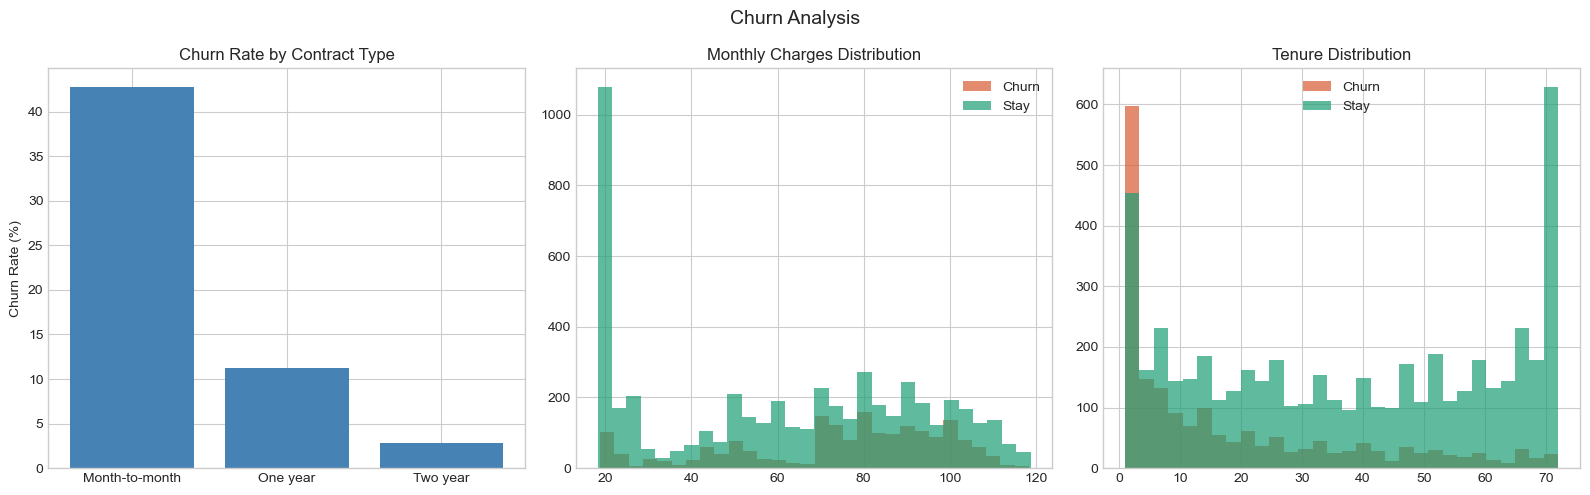

In [11]:
# EDA — Churn rate ตาม contract type
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Churn Analysis', fontsize=14)

# 1. Churn by Contract
churn_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
axes[0].bar(churn_contract['Contract'], churn_contract['Churn'], color='steelblue')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate (%)')

# 2. Monthly Charges distribution
df[df['Churn']=='Yes']['MonthlyCharges'].hist(ax=axes[1], alpha=0.7, label='Churn', bins=30, color='#D85A30')
df[df['Churn']=='No']['MonthlyCharges'].hist(ax=axes[1], alpha=0.7, label='Stay', bins=30, color='#1D9E75')
axes[1].set_title('Monthly Charges Distribution')
axes[1].legend()

# 3. Tenure distribution
df[df['Churn']=='Yes']['tenure'].hist(ax=axes[2], alpha=0.7, label='Churn', bins=30, color='#D85A30')
df[df['Churn']=='No']['tenure'].hist(ax=axes[2], alpha=0.7, label='Stay', bins=30, color='#1D9E75')
axes[2].set_title('Tenure Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/figures/01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# แปลง binary columns เป็น 0/1
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# One-hot encoding สำหรับ categorical columns ที่มีมากกว่า 2 ค่า
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract',
            'PaymentMethod']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Features หลัง encoding: {df.shape[1]-1}")
print(df.head(2))

Features หลัง encoding: 30
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  \
0                 1           29.85         29.85      0   
1                 0           56.95       1889.50      0   

   MultipleLines_No phone service  MultipleLines_Yes  \
0                            True              False   
1                           False              False   

   InternetService_Fiber optic  InternetService_No  \
0                        False               False   
1                        False               False   

   OnlineSecurity_No internet service  OnlineSecurity_Yes  \
0                               False               False   
1                               False                True   

   OnlineBackup_No internet service  OnlineBackup_Yes  \
0    

In [13]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")
print(f"Churn rate ใน test: {y_test.mean()*100:.1f}%")

# บันทึก feature names ไว้ใช้ใน app
feature_names = X.columns.tolist()
print(f"\nFeatures: {len(feature_names)}")

Train: 5,625 rows
Test:  1,407 rows
Churn rate ใน test: 26.6%

Features: 30


In [19]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'auc':       roc_auc_score(y_test, y_prob),
        'report':    classification_report(y_test, y_pred,
                     target_names=['Stay', 'Churn'])
    }
    print(f"\n=== {name} ===")
    print(results[name]['report'])
    print(f"AUC-ROC: {results[name]['auc']:.3f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

AUC-ROC: 0.836

=== Random Forest ===
              precision    recall  f1-score   support

        Stay       0.83      0.89      0.86      1033
       Churn       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

AUC-ROC: 0.814

=== XGBoost ===
              precision    recall  f1-score   support

        Stay       0.84      0.86      0.85      1033
       Churn       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      

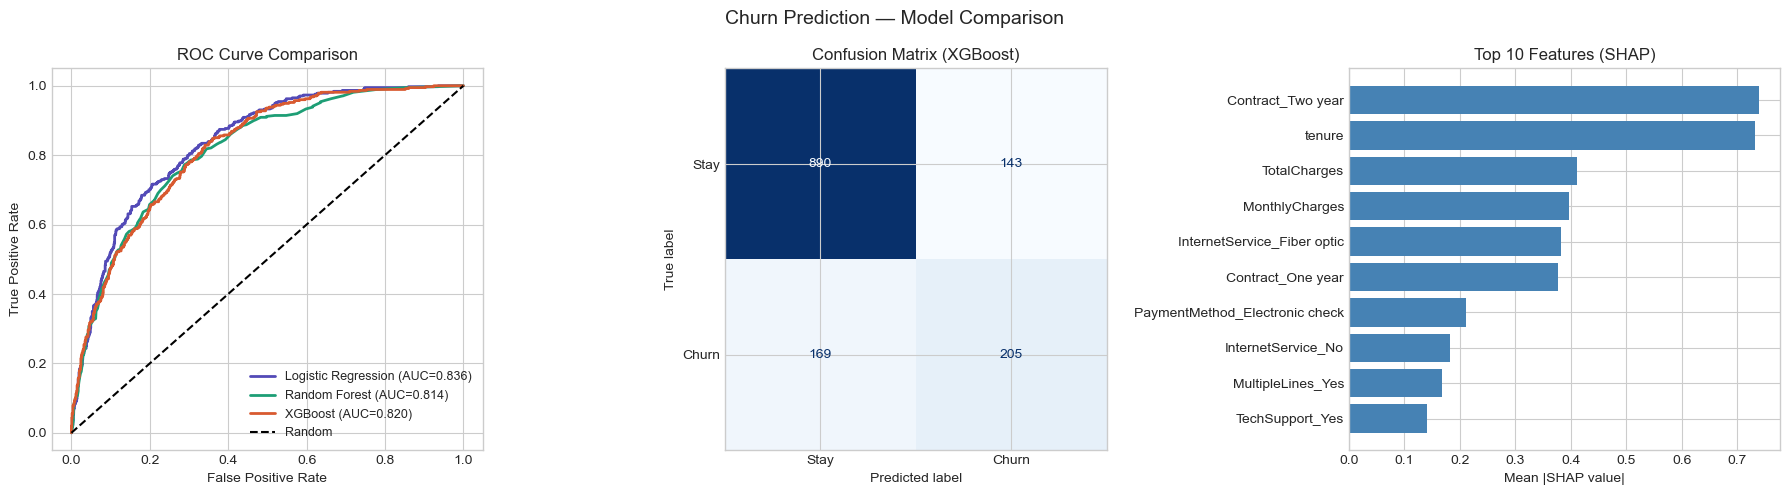

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Churn Prediction — Model Comparison', fontsize=14)

# 1. ROC Curve
colors = ['#534AB7', '#1D9E75', '#D85A30']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})",
                 linewidth=2, color=color)
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# 2. Confusion Matrix ของ XGBoost
cm = confusion_matrix(y_test, results['XGBoost']['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix (XGBoost)')

# 3. SHAP Feature Importance
explainer   = shap.TreeExplainer(results['XGBoost']['model'])
shap_values = explainer.shap_values(X_test_sc)
shap_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': np.abs(shap_values).mean(0)
}).sort_values('importance', ascending=True).tail(10)

axes[2].barh(shap_df['feature'], shap_df['importance'], color='steelblue')
axes[2].set_title('Top 10 Features (SHAP)')
axes[2].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig('../reports/figures/02_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import pickle

# บันทึก XGBoost model (ดีที่สุด)
with open('../models/xgb_model.pkl', 'wb') as f:
    pickle.dump(results['XGBoost']['model'], f)

# บันทึก scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# บันทึก feature names
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("✅ บันทึก model เสร็จแล้ว")
print(f"   models/xgb_model.pkl")
print(f"   models/scaler.pkl")
print(f"   models/feature_names.pkl")

✅ บันทึก model เสร็จแล้ว
   models/xgb_model.pkl
   models/scaler.pkl
   models/feature_names.pkl
